# DM1580 Project  
# Build and Explore a Video Compression System

This is the **2026 version** of the project notebook.

It is designed to be:
- conceptually rigorous
- clearly scaffolded
- coherent as a single project
- realistic for students to complete
- easy to supervise and assess

This project is graded **Pass / Fail**.

## Project overview

In this project, you will design, implement, and evaluate a simplified video compression system.

The goal is not only to make a pipeline run, but to understand how a compression system works as a sequence of representations and decisions:

- an image becomes a signal
- a signal is transformed into coefficients
- coefficients are quantized and coded
- temporal redundancy is exploited through prediction
- quality, rate, and complexity must be balanced

You will first build a basic intraframe codec, then extend it to predictive coding, and finally evaluate the system on a full video sequence.

## Deliverables

You must submit **one single Jupyter notebook** containing:

### A. System implementation
Your complete codec pipeline.

### B. Results
Visual and numerical outputs from the pipeline.

### C. Experiments
At least two required experiments.

### D. Analysis
Short written answers interpreting your results.

### E. Individual reflection
A short personal reflection from each student.

Your notebook must be:
- self-contained
- clearly structured
- executable from start to finish
- understandable to a reader

## Minimum working system

To pass, your project must include at least the following:

### Stage 1
A working intraframe codec on one frame:
- RGB → Y
- 8×8 block splitting
- DCT
- quantization
- Huffman coding of quantized DCT coefficients
- inverse quantization
- inverse DCT
- reconstruction
- PSNR

### Stage 2
A working predictive codec on at least two frames:
- reference frame
- prediction
- residual
- compression of the residual
- reconstruction of target frame

### Stage 3
Whole-video evaluation on at least 30 consecutive frames:
- frame-by-frame reconstruction
- average PSNR
- at least one compression-related measure
- one plot showing behavior over time

## Recommended workflow

Do not try to solve everything at once.

Recommended order:
1. extract frames and build the intraframe pipeline
2. verify reconstruction and PSNR
3. construct and interpret DCT basis functions
4. add Huffman coding of quantized coefficients
5. extend to predictive coding
6. enforce the DPCM principle
7. run experiments
8. write analysis using your own results as evidence

## Group information

**Group number:**  13

**Member 1:**  Nora Sennerö

**Member 2:**  Erik Esshagen

# A. Project proposal snapshot

Write a short project snapshot before implementing.

## Goal
This section should make your project understandable before the reader sees code.

### Problem definition
We chose the standard problem. That includes turning the image into coeficcients using DCT, and compression using quantization, huffman-coding (lossless) and prediction.

### Technical approach
After loading the image(s), we will turn the RGB values into one Y channel. For DCT, the image has to be split into 8x8 blocks. We quantize by dividing by 10 and rounding up to the nearest integer. Then we will huffman-code, which turns the symbols into sequences with different lengths, depending on their rarity. For prediction we will use frame differencing, which means calculating the differences between two consecutive frames; and then compressing the difference, and then add that back to the first image.

### Planned evaluation
The results will be evaluated by calculating the entropy and the PSNR between the original and reconstructed frames. The results can also be visualized by plotting the images before and after compression, as well as the error/difference between the two. We will do the pipeline over multiple frames to see how it diferenciates over time.

### Expected insights
Quantization should give visible reconstruction error; but not huffman-coding because it's lossless. Prediction should also give reconstruction error. The PSNR and entropy should change over time, based on how much differs between the frames (how predictable they are).

# B. Imports and setup

## Goal
Prepare your environment and define your basic project settings.

## Deliverable
A clean setup section with imports, paths, constants, and optional helper configuration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
from scipy.fftpack import dct, idct
import cv2

VIDEO_PATH = "test video.mp4"
FRAME_INDEX_INTRA = 80
FRAME_INDEX_REF = 80
FRAME_INDEX_TARGET = 85
BLOCK_SIZE = 8
DEFAULT_Q = 10
WHOLE_VIDEO_FRAMES = 30

# C. Frame extraction and preprocessing

## Goal
Load the video and extract the frames needed for Stage 1 and Stage 2.

## Tasks
- load the video
- extract the required frames
- display the selected frames
- explain your frame selection if needed

## Minimum deliverable
Show:
- one frame for intraframe compression
- one reference frame
- one target frame

In [2]:
def generate_fallback_frame(index, height=240, width=320):
    """Generate a synthetic RGB frame for fallback use."""
    x = np.linspace(0, 255, width, dtype=np.float32)
    y = np.linspace(0, 255, height, dtype=np.float32)
    X, Y = np.meshgrid(x, y)

    shift = index * 2.0
    R = np.mod(X + shift, 256)
    G = np.mod(Y + 0.5 * shift, 256)
    B = np.mod(0.5 * X + 0.5 * Y + shift, 256)

    frame = np.stack([R, G, B], axis=2)
    return np.clip(frame, 0, 255).astype(np.uint8)

def extract_video_frames(video_name, indices):
    cap = cv2.VideoCapture(video_name)

    if not cap.isOpened():
        print("Could not open the video file. Using fallback synthetic frames.")
        return {idx: generate_fallback_frame(idx) for idx in indices}

    frames = {}
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        _, frame = cap.read()
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames[idx] = frame_rgb

    cap.release()
    return frames

frames = extract_video_frames(VIDEO_PATH, [FRAME_INDEX_INTRA, FRAME_INDEX_REF, FRAME_INDEX_TARGET])

intra_rgb = frames[FRAME_INDEX_INTRA]
ref_rgb = frames[FRAME_INDEX_REF]
target_rgb = frames[FRAME_INDEX_TARGET]

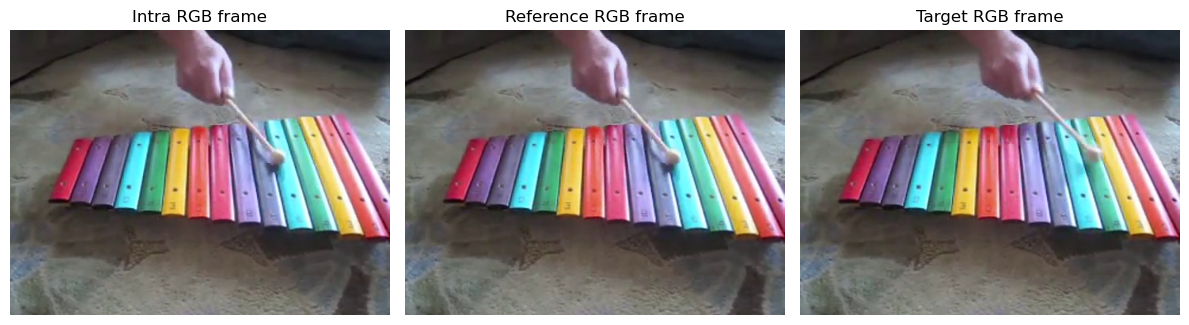

In [3]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(intra_rgb)
plt.title("Intra RGB frame")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ref_rgb)
plt.title("Reference RGB frame")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(target_rgb)
plt.title("Target RGB frame")
plt.axis("off")

plt.tight_layout()
plt.show()

### Short note on frame selection
Briefly explain why these frames are reasonable choices for your project.

We used the frames declared in the setup on B. The first frame is used independently from the others, so it doesn't matter which it is. The others will be used for prediction, so they have to be close to each other. However, it can be useful to not use two consecutive frames, since they could be too similar to give visible difference in the result.

# D. Stage 1 — Intraframe compression

This stage builds your intraframe codec and its theoretical foundation.

## D1. Construct the DCT basis

## Goal
Understand the DCT as a basis representation, not as a black box.

## Mathematical definition

For a 1×8 block, the 1D DCT basis functions are:

$$
b_k(n)=c_k \cos\left(\frac{\pi k(2n+1)}{2N}\right), \qquad n=0,1,2,\dots,N-1
$$

where:

- $n$ is the element index within the block
- $k$ is the basis index
- $N=8$
- $c_k$ is the normalization factor

$$
c_k=
\begin{cases}
\sqrt{\frac{1}{N}}, & \text{if } k=0 \\
\sqrt{\frac{2}{N}}, & \text{if } k>0
\end{cases}
$$

The 2D basis functions are formed by the outer product of two 1D basis functions:

$$
B_{u,v}(m,n)=b_u(m)b_v(n)
$$

## Tasks
- construct the 1D DCT basis matrix
- construct the 2D 8×8 basis functions
- visualize at least 4 example basis functions

## Deliverable
Show:
- the 8×8 DCT basis matrix
- at least 4 example 2D basis functions

[[ 0.354  0.354  0.354  0.354  0.354  0.354  0.354  0.354]
 [ 0.49   0.416  0.278  0.098 -0.098 -0.278 -0.416 -0.49 ]
 [ 0.462  0.191 -0.191 -0.462 -0.462 -0.191  0.191  0.462]
 [ 0.416 -0.098 -0.49  -0.278  0.278  0.49   0.098 -0.416]
 [ 0.354 -0.354 -0.354  0.354  0.354 -0.354 -0.354  0.354]
 [ 0.278 -0.49   0.098  0.416 -0.416 -0.098  0.49  -0.278]
 [ 0.191 -0.462  0.462 -0.191 -0.191  0.462 -0.462  0.191]
 [ 0.098 -0.278  0.416 -0.49   0.49  -0.416  0.278 -0.098]]


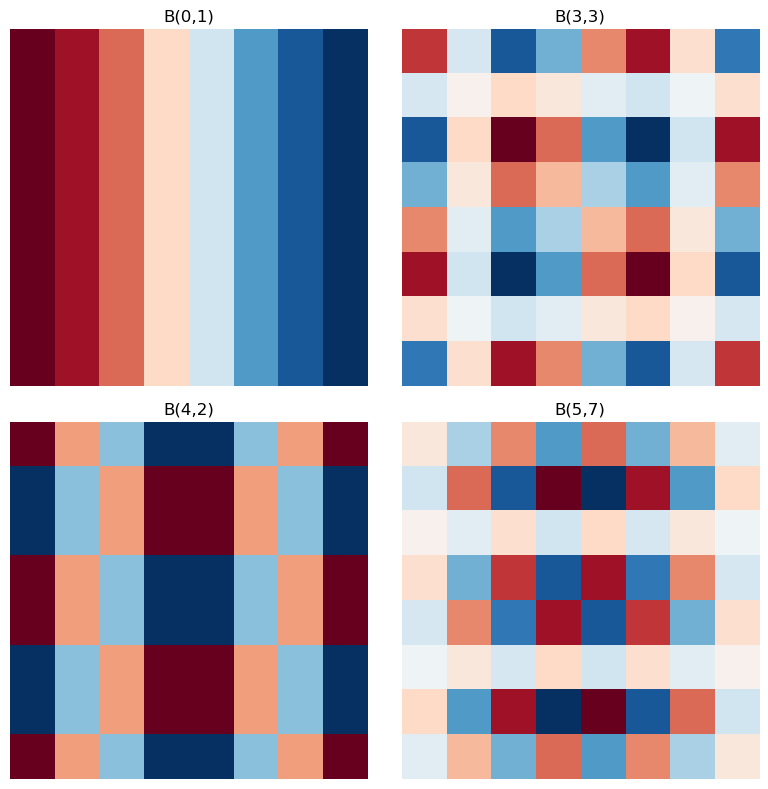

In [ ]:
# TODO: construct the 1D DCT basis matrix

def dct_1d_basis_matrix(N):
    Bk = np.zeros((N,N))

    for k in range(N):
        for n in range(N):
            if k == 0:
                ck = np.sqrt(1/N)
            else:
                ck = np.sqrt(2/N)

            Bk[k, n] = ck * np.cos((np.pi * k * (2*n + 1))/(2 * N))

    return Bk

def dct_2d_basis(C):
    N = C.shape[0]
    B = np.zeros((N, N, N, N))  # (u, v, x, y)

    for u in range(N):
        for v in range(N):
            B[u, v] = np.outer(C[u], C[v])

    return B

print(np.round(dct_1d_basis_matrix(8),3))
B = dct_2d_basis(dct_1d_basis_matrix(8))

examples = [(0,1), (3,3), (4,2), (5,7)]

plt.figure(figsize=(8, 8))

for i, (u, v) in enumerate(examples):
    plt.subplot(2, 2, i+1)
    plt.imshow(B[u, v], cmap='RdBu_r')
    plt.title(f"B({u},{v})")
    plt.axis('off')

plt.tight_layout()
plt.show()
# TODO: construct the 2D 8x8 basis functions
# TODO: visualize at least 4 example basis functions

### Reflection
Use your own basis visualizations as evidence.

- What do low-frequency basis functions represent?
- What do high-frequency basis functions represent?
- Why is it useful that many natural-image blocks can often be represented mainly by low-frequency basis functions?

Write your reflection here.
1. little variance in the image (top left)
2. Much varation in the image (like sharp edges)
3. High-frequency coefficients can be quantized aggressively or discarded entirely with minimal visible loss.



## D2. Build the intraframe pipeline

## Goal
Compress one frame using transform coding.

## Required components
You must implement:
- RGB → Y conversion
- block splitting
- DCT
- quantization
- Huffman coding of quantized DCT coefficients
- inverse quantization
- inverse DCT
- block merging
- reconstruction
- PSNR

## Hint
Keep your helper functions small and testable.

In [5]:
# TODO: define helper functions for:

# rgb2y
def frameRGB2YUV(RGBframe):
    RGBframe = RGBframe.astype(np.float32)
    RGBframe = RGBframe.astype(np.float32)

    R = RGBframe[:, :, 0]
    G = RGBframe[:, :, 1]
    B = RGBframe[:, :, 2]

    Y = (0.299 * R) + (0.587 * G) + (0.114 * B)
    return Y


# block_split
def block_split(img, block_size=BLOCK_SIZE):
    h, w = img.shape
    blocks = []

    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            block = img[i:i+block_size, j:j+block_size]
            blocks.append(block)
    return blocks

# block_merge
def block_merge(blocks, image_shape, block_size=BLOCK_SIZE):
    h, w = image_shape
    img = np.zeros((h, w), dtype=np.float32)

    idx = 0
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            img[i:i+block_size, j:j+block_size] = blocks[idx]
            idx += 1

    return img

# dct2
def dct2(x):
    return dct(dct(x, axis=0, norm='ortho'), axis=1, norm='ortho')

# idct2
def idct2(x):
    return idct(idct(x, axis=0, norm='ortho'), axis=1, norm='ortho')

# psnr
def CalculatePSNR(im1, im2):
    if im1.shape != im2.shape:
        raise ValueError("Images must have the same shape.")

    # TODO: convert to float
    im1 = im1.astype(np.float32)
    im2 = im2.astype(np.float32)

    # TODO: compute mean squared error
    mse = np.mean((im1 - im2) ** 2)

    if mse == 0:
        return float("inf")

    # TODO: compute PSNR
    psnr = 10 * np.log10((255**2) / mse)
    return psnr

## D3. Huffman coding requirement

## Goal
Code the quantized DCT coefficients with Huffman coding.

## Minimum steps
- flatten the quantized coefficients
- compute symbol probabilities
- build a Huffman dictionary
- encode the coefficients into a bitstream
- decode the bitstream
- verify exact symbol recovery before reconstruction

## Important
Huffman coding is **lossless**.
Any distortion in the reconstructed image should come from **quantization**, not from Huffman coding.

In [6]:
# TODO: define helper functions for:

# build_symbol_probabilities
def build_symbol_probabilities(data):

    flat = data.flatten()
    values, counts = np.unique(flat, return_counts=True)
    total = counts.sum()
    probs = {val: count / total for val, count in zip(values, counts)}
    return probs

# build_huffman_dict
def Huffmandict(p):
    """Generate a Huffman code dictionary from a probability dictionary."""
    heap = [[prob, [symbol, ""]] for symbol, prob in p.items()]
    heapq.heapify(heap)

    if len(heap) == 0:
        return {}
    if len(heap) == 1:
        symbol = heap[0][1][0]
        return {symbol: "0"}

    while len(heap) > 1:
        lo = heapq.heappop(heap)
        hi = heapq.heappop(heap)

        for pair in lo[1:]:
            pair[1] = "0" + pair[1]
        for pair in hi[1:]:
            pair[1] = "1" + pair[1]

        # TODO: push merged node back into the heap
        heapq.heappush(heap, [lo[0] + hi[0]] + lo[1:] + hi[1:])

    huff_list = sorted(heap[0][1:], key=lambda pair: (len(pair[1]), str(pair[0])))
    huff_dict = {symbol: codeword for symbol, codeword in huff_list}
    return huff_dict

# huffman_encode
def Huffmanenco(OriginalImage, Huffdict):
    """Perform Huffman encoding on an integer image and return a bitstream string."""
    flat = OriginalImage.flatten()

    # TODO: replace each symbol by its Huffman codeword
    encoded = "".join(Huffdict[symbol] for symbol in flat)
    return encoded

# huffman_decode
def Huffmandeco(EncodedImage, Huffdict, shape):
    """Decode a Huffman bitstream back into an integer image."""
    reverse_dict = {v: k for k, v in Huffdict.items()}

    decoded_symbols = []
    buffer = ""

    for bit in EncodedImage:
        buffer += bit
        if buffer in reverse_dict:
            decoded_symbols.append(reverse_dict[buffer])
            buffer = ""
    decoded = np.array(decoded_symbols).reshape(shape)
    return decoded

# optional: bits_per_symbol or approximate coding rate
def bits_per_symbol(encoded_bitstream, original_data):
    total_bits = len(encoded_bitstream)
    num_symbols = original_data.size
    return total_bits / num_symbols

In [7]:
# TODO: build the intraframe pipeline
    # intra_y
def intraframe_pipeline(frame, quantization=DEFAULT_Q):

    intra_y = frameRGB2YUV(intra_rgb)

    #blocks
    blocks = block_split(intra_y)

    #dct_blocks
    dct_blocks = [dct2(block) for block in blocks]

    #q_blocks
    q_blocks = [np.round(b / quantization).astype(int) for b in dct_blocks]

    #huff_dict
    q_flat = np.concatenate([b.flatten() for b in q_blocks])
    huff_dict = Huffmandict(build_symbol_probabilities(q_flat))

    # bitstream
    bitstream = Huffmanenco(q_flat, huff_dict)

    # q_blocks_decoded
    decoded_flat = Huffmandeco(bitstream, huff_dict, q_flat.shape)
    q_blocks_decoded = []
    for i in range(len(q_blocks)):
        q_blocks_decoded.append(decoded_flat[i*64:(i+1)*64].reshape(8,8))


    # intra_y_reconstructed
    reconstructed_blocks = [idct2(b * quantization) for b in q_blocks_decoded]
    intra_y_reconstructed = block_merge(reconstructed_blocks, intra_y.shape)
    intra_y_reconstructed = np.clip(intra_y_reconstructed, 0, 255).astype(np.uint8)

    # intra_psnr
    intra_psnr = CalculatePSNR(intra_y, intra_y_reconstructed)

    return intra_y, intra_y_reconstructed, blocks, dct_blocks, q_blocks, q_blocks_decoded, intra_psnr

intra_y, intra_y_reconstructed, blocks, dct_blocks, q_blocks, q_blocks_decoded, intra_psnr = intraframe_pipeline(intra_rgb)

Huffman lossless check: True


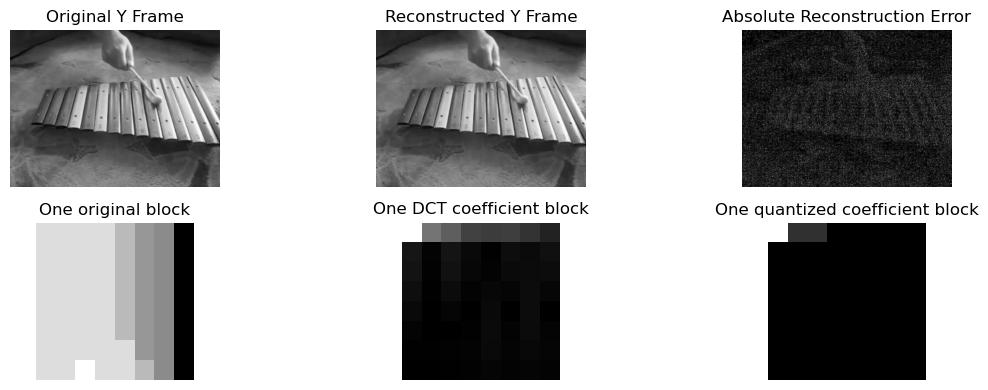

In [8]:
# TODO: show
plt.figure(figsize=(12, 4))

# - original Y frame
plt.subplot(2, 3, 1)
plt.imshow(intra_y, cmap="gray")
plt.title("Original Y Frame")
plt.axis("off")

# - reconstructed Y frame
plt.subplot(2, 3, 2)
plt.imshow(intra_y_reconstructed, cmap="gray")
plt.title("Reconstructed Y Frame")
plt.axis("off")

# - error image
recon_diff = np.abs(intra_y.astype(np.int16) - intra_y_reconstructed.astype(np.int16))
plt.subplot(2, 3, 3)
plt.imshow(recon_diff, cmap="gray")
plt.title("Absolute Reconstruction Error")
plt.axis("off")


# - one original block
plt.subplot(2, 3, 4)
plt.imshow(blocks[5], cmap="gray")
plt.title("One original block")
plt.axis("off")


# - one DCT coefficient block
plt.subplot(2, 3, 5)
plt.imshow(np.log1p(np.abs(dct_blocks[5])), cmap="gray")
plt.title("One DCT coefficient block")
plt.axis("off")


# - one quantized coefficient block
plt.subplot(2, 3, 6)
plt.imshow(np.log1p(np.abs(q_blocks[5])), cmap="gray")
plt.title("One quantized coefficient block")
plt.axis("off")

# - one statement confirming that Huffman decoding recovers the quantized coefficients exactly
recovered_flat = np.concatenate([b.flatten() for b in q_blocks_decoded])
original_flat = np.concatenate([b.flatten() for b in q_blocks])

print("Huffman lossless check:", np.array_equal(recovered_flat, original_flat))

plt.tight_layout()
plt.show()

### Stage 1 analysis

Use your outputs as evidence.

Discuss:
- which coefficients dominate in natural image blocks
- what information is preserved after DCT
- what artifacts appear after quantization
- how Huffman coding helps after quantization
- why Huffman coding does not itself create distortion

Write your Stage 1 analysis here.
1. Low frequency coefficients
2. Everything should be preserved after DCT because it's lossless.
3. Just from looking at the output image, there are no clear artifacts that appeared. However, we can see some loss in contrast and edges. Because the quantization is done for every 8x8 block, that can lead to a grid-pattern in the image, which might be what is seen in the error image.
4. Quantization will create more of the same value, which will lead to shorter huffman-codes (since more common values get shorter sequences)
5. Because it's lossless. Every symbol gets translated to unique code, so it's possible to decode and get the exact same information.

# E. Stage 2 — Predictive compression

This stage extends your system to temporal compression.

## E1. Choose and describe your prediction method

## Goal
Define how you predict the target frame from the reference frame.

## Allowed options
- simple frame differencing
- block matching or motion-based prediction

## Deliverable
Write 3–5 clear sentences explaining:
- what you predict
- how you compute the residual
- what assumptions your method makes

We use simple frame differencing to predict the target frame from the reference frame. In this method, the previous frame is used directly as the prediction for the current frame, assuming that consecutive frames are very similar. The residual is computed by subtracting the reference frame from the target frame on a pixel-by-pixel basis, leaving only the changes between the two frames.

This approach assumes that motion between frames is small and that most areas of the image remain unchanged over time. It also works best when there are no sudden scene changes or large movements between consecutive frames.

## E2. Critical rule: DPCM principle

When performing frame prediction, you must always use the **reconstructed previous frame**, not the original previous frame, to predict the current frame.

This is essential.

If your system uses temporal prediction, then:
- the encoder predicts from the reconstructed previous frame
- the decoder does the same

This prevents mismatch and follows the DPCM principle.

## E3. Build the predictive pipeline

## Goal
Compress the residual using your intraframe machinery.

## Required components
- reference frame
- target frame
- prediction
- residual
- transform and quantization of residual
- Huffman coding of quantized residual coefficients
- residual reconstruction
- target reconstruction
- PSNR

## Minimum deliverable
Show:
- reference frame
- target frame
- predicted frame
- residual visualization
- reconstructed target frame
- reconstruction error

In [9]:
# TODO: implement predictive coding with the DPCM principle
# Suggested outputs:

# ref_y, target_y, pred_y, residual
ref_y = frameRGB2YUV(ref_rgb)
target_y = frameRGB2YUV(target_rgb)
pred_y = ref_y
residual = target_y - pred_y

# residual_dct, residual_q
residual_dct = dct2(residual)
residual_q = np.round(residual_dct / DEFAULT_Q).astype(int)


# residual_huff_dict, residual_bitstream
residual_huff_dict = Huffmandict(build_symbol_probabilities(residual_q.flatten()))
residual_bitstream = Huffmanenco(residual_q.flatten(), residual_huff_dict)

# residual_q_decoded
residual_q_decoded = Huffmandeco(residual_bitstream, residual_huff_dict, residual_q.shape)
residual_decoded = idct2(residual_q_decoded * DEFAULT_Q)

# target_y_reconstructed, target_psnr
target_y_reconstructed = ref_y + residual_decoded
target_psnr = CalculatePSNR(target_y, target_y_reconstructed)


(np.float64(-0.5), np.float64(479.5), np.float64(359.5), np.float64(-0.5))

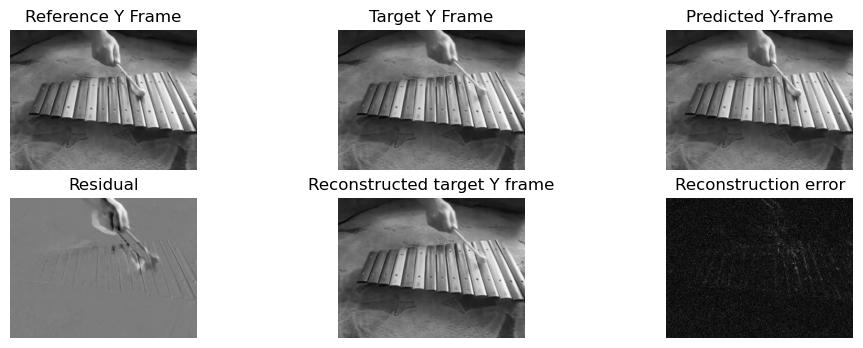

In [10]:
# TODO: visualize
plt.figure(figsize=(12, 4))

# - reference frame
plt.subplot(2, 3, 1)
plt.imshow(ref_y, cmap="gray")
plt.title("Reference Y Frame")
plt.axis("off")

# - target frame
plt.subplot(2, 3, 2)
plt.imshow(target_y, cmap="gray")
plt.title("Target Y Frame")
plt.axis("off")


# - predicted frame
plt.subplot(2, 3, 3)
plt.imshow(pred_y, cmap="gray")
plt.title("Predicted Y-frame")
plt.axis("off")


# - residual
plt.subplot(2, 3, 4)
plt.imshow(residual, cmap="gray")
plt.title("Residual")
plt.axis("off")

# - reconstructed target frame
plt.subplot(2, 3, 5)
plt.imshow(target_y_reconstructed, cmap="gray")
plt.title("Reconstructed target Y frame")
plt.axis("off")

# - reconstruction error
recon_error = np.abs(target_y.astype(np.int16) - target_y_reconstructed.astype(np.int16))
plt.subplot(2, 3, 6)
plt.imshow(recon_error, cmap="gray")
plt.title("Reconstruction error")
plt.axis("off")

### Stage 2 analysis

Use your outputs as evidence.

Discuss:
- why the residual is often easier to compress
- what assumptions your prediction method makes
- when the prediction fails
- why the DPCM principle matters
- what role Huffman coding plays for the residual

Write your Stage 2 analysis here.
1. Because it's the difference between two frames. There is often less information in the movement between the frames (in this case most of the image is static), compared to compressing all the information in an original frame.
2. That the predicted frame is the same as the previous/reference. (see reference frame and predicted frame)
3. When the two frames are too different (much movement/changes)
4. Otherwise, the encoder predicts from the original frame and the encoder uses the reconstruction, which will lead to errors that diverge when more frames are processed.
5. Similarly to quantization, Huffman is useful and effective when there is little information/most symbols are the same.

# F. Stage 3 — System evaluation and experiments

This is the most important stage.

You must complete **two required experiments**.

## F1. Experiment 1 — Quantization study

## Goal
Study how quantization changes quality and coding behavior.

## Requirement
Test at least **three** quantization settings.

For each setting, report:
- PSNR
- one compression-related measure
- one visual observation

### Acceptable compression-related measures
- entropy of quantized coefficients
- percentage of zero coefficients
- approximate coding rate
- Huffman rate

## Minimum deliverable
At least:
- one plot of quantization level vs PSNR
- one additional comparison, for example:
  - quantization level vs Huffman rate
  - quantization level vs zero coefficient ratio
  - quantization level vs entropy

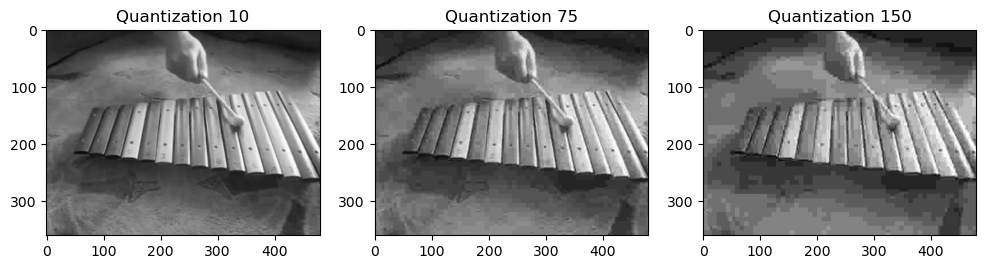

In [11]:
# TODO: run Experiment 1
# Suggested metrics:

def compute_entropy(data):
    _, counts = np.unique(data, return_counts=True)
    probs = counts / counts.sum()
    entropy = -np.sum(probs * np.log2(probs))
    return entropy


# - PSNR
# - entropy of quantized coefficients

quantization_settings = [2, 10, 25, 50, 75, 100, 150, 200]
psnr_list = []
entropy_list = []

plt.figure(figsize=(12, 4))

for quant_setting in quantization_settings:
    intra_y, intra_y_reconstructed, blocks, dct_blocks, q_blocks, q_blocks_decoded, intra_psnr = intraframe_pipeline(intra_rgb, quant_setting)
    if quant_setting == 10:
        plt.subplot(1, 3, 1)
        plt.imshow(intra_y_reconstructed, cmap="gray")
        plt.title("Quantization 10")


    if quant_setting == 75:
        plt.subplot(1, 3, 2)
        plt.imshow(intra_y_reconstructed, cmap="gray")
        plt.title("Quantization 75")

    if quant_setting == 150:
        plt.subplot(1, 3, 3)
        plt.imshow(intra_y_reconstructed, cmap="gray")
        plt.title("Quantization 150")
    psnr_list.append(intra_psnr)
    entropy_list.append(compute_entropy(q_blocks))

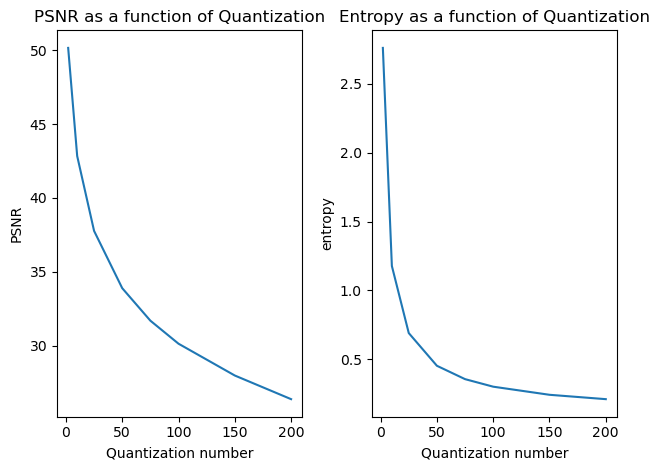

In [12]:
plt.subplot(1, 2, 1)
plt.plot(quantization_settings, psnr_list)
plt.title("PSNR as a function of Quantization")
plt.xlabel("Quantization number")
plt.ylabel("PSNR")

plt.subplot(1, 2, 2)
plt.plot(quantization_settings, entropy_list)
plt.title("Entropy as a function of Quantization")
plt.xlabel("Quantization number")
plt.ylabel("entropy")

plt.tight_layout()
plt.show()

### Experiment 1 discussion

Use your own plots as evidence.

Explain:
- how quantization affects low and high frequencies
- why stronger quantization changes visual quality
- what trade-off you observe

Write your Experiment 1 discussion here.
1. High quantization number affects both high and low frequencies, but high frequencies more, since their coefficients are already low.
2. The high frequency coefficients will disappear more and leave the image blurry.
3. Higher quantization number makes it easier to compress, but leads to worse quality/information loss (lower PSNR as seen in the graph)

## F2. Experiment 2 — Whole-video compression experiment

## Goal
Evaluate your system over time.

## Requirement
Apply your system to the whole video, or at least a continuous segment of **30 or more frames**.

## Required outputs
Report:
- average PSNR over time
- one compression-related measure over time
- one plot of frame index vs PSNR
- one short discussion of temporal behavior

## Important reminder
When performing frame prediction, always use the **reconstructed previous frame**, not the original previous frame, to predict the current frame.

### Recommended whole-video algorithm skeleton

A safe structure is:

- frame 0: intraframe compression
- frame 1, 2, 3, ...:
  - predict from the reconstructed previous frame
  - compute residual
  - compress the residual
  - reconstruct the current frame
  - store the reconstructed current frame for the next prediction

This is where many projects fail, so be explicit in your implementation.

In [16]:
# TODO: run Experiment 2 on the whole video (or 30+ consecutive frames)
frame_numbers = []
for i in range(30):
    frame_numbers.append(i+80)

frames = extract_video_frames(VIDEO_PATH, frame_numbers)
intra_y, intra_y_reconstructed, blocks, dct_blocks, q_blocks, q_blocks_decoded, intra_psnr = intraframe_pipeline(frames[frame_numbers[0]])
start_frame = intra_y_reconstructed

psnr_over_time = []
entropy_over_time = []
for i in range(len(frames)-1):
    ref_y = start_frame
    current_frame_number = frame_numbers[i + 1]
    target_y = frameRGB2YUV(frames[current_frame_number])
    pred_y = ref_y
    residual = target_y - pred_y

    residual_dct = dct2(residual)
    residual_q = np.round(residual_dct / DEFAULT_Q).astype(int)

    # residual_huff_dict, residual_bitstream
    residual_huff_dict = Huffmandict(build_symbol_probabilities(residual_q.flatten()))
    residual_bitstream = Huffmanenco(residual_q.flatten(), residual_huff_dict)

    # residual_q_decoded
    residual_q_decoded = Huffmandeco(residual_bitstream, residual_huff_dict, residual_q.shape)
    residual_decoded = idct2(residual_q_decoded * DEFAULT_Q)

    # target_y_reconstructed, target_psnr
    target_y_reconstructed = ref_y + residual_decoded
    psnr_over_time.append(CalculatePSNR(target_y, target_y_reconstructed))
    entropy_over_time.append(compute_entropy(residual_q.flatten()))

    start_frame = target_y_reconstructed

average_psnr = np.average(psnr_over_time)
print(average_psnr)

40.989532


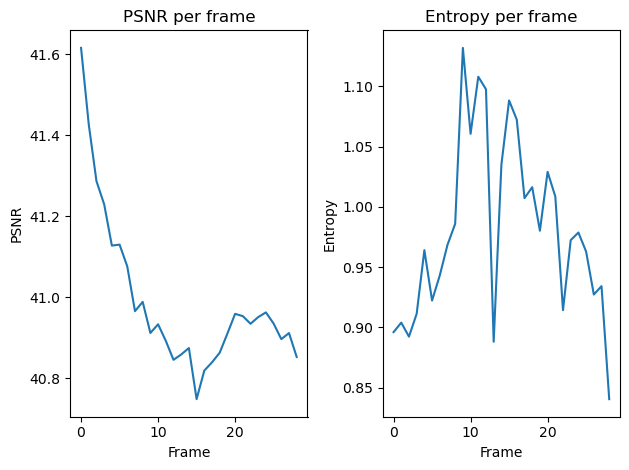

In [17]:
plt.subplot(1, 2, 1)
plt.plot(psnr_over_time)
plt.title("PSNR per frame")
plt.xlabel("Frame")
plt.ylabel("PSNR")

plt.subplot(1, 2, 2)
plt.plot(entropy_over_time)
plt.title("Entropy per frame")
plt.xlabel("Frame")
plt.ylabel("Entropy")

plt.tight_layout()
plt.show()

### Experiment 2 discussion

Use your own results as evidence.

Explain:
- whether quality remains stable over time
- whether error accumulation appears
- whether your prediction method behaves differently in different scenes
- whether the DPCM principle matters in practice

Write your Experiment 2 discussion here.
Explain:
1. PSNR seems to indicate relatively stable quality with a small decline from 41.6 to 40.7. The entropy changed from around 1.15 to 0.85, with most of the data around 1 meaning the entropy was relativly small, this indicates frame differences were predictable.

2. Error accumulation is bound to happen due to the nature of user the previous reconstructed frame as the predictor. However, the realtively constant PSNR indicates that this had little effect on the actual video.

3. The prediction method performs differently in different scenes,
and it is based on the complexity of the scene and its motion. Small motion or gradual changes means that the residual is small and therefore the entropy becomes lower,
PSNR higher and the compression is more efficient.

4. This experiment shows that DPCM is a good way to compress video in practice. By only compressing the difference of frames, which is often very little, the residual signal often has lower entropy than the original image data which improves compression efficiency.

## F3. Optional third experiment

Students aiming for stronger projects may add one extra experiment, for example:
- intraframe vs predictive coding comparison
- residual statistics before and after prediction
- different block sizes
- different quantization strategies
- simple difference vs block matching
- rate–distortion comparison

In [15]:
# Optional: add a third experiment here

# G. Final analysis

Your notebook must answer these questions clearly.

Use your own results as evidence whenever possible.

## A. DCT and representation
- What is the role of DCT in compression?
- Why are low-frequency components often more important than high-frequency components?

## B. Quantization
- How does quantization affect different frequencies?
- Why does quantization introduce distortion?

## C. Prediction
- Why does predictive coding often improve efficiency?
- Why must the reconstructed previous frame be used instead of the original previous frame?

## D. System behavior
- What are the limitations of your system?
- What trade-offs did you observe between quality, coding rate, and complexity?
- How did your system behave over time on the whole video?

Write your final analysis here.
The DCT itself does not compress because it's the same amount of coefficients as pixel values, just in the frequency domain. But it reorganizes the signal into coefficients which can be compressed (with quantization, which would not work on just the pixel values. There would also be no point in using huffman-code on the pixel-values if they're evenly spread out between 0-255). 

Low frequencies are often more important because they dominate in natural images (smooth objects). Us humans also wouldn't recognize a loss in high-frequencies as much.
Quantization affects all frequencies, but high frequencies more, since they already have low components, which can be rounded to zero with a high quantization number. Quantization introduces distortion because it replaces each coefficient with a rounded number, so some information will be lost.

Predictive coding often improves efficiency because it only codes what's changed between frames. Usually very little happens between frames, so it's less information compared to the whole original frame. You have to use the previous reconstructed frame because that's what the decoder uses. If the encoder predicts from the original but the decoder predicts from the reconstruction, their predictions differ by the quantization error of the previous frame. That error enters the residual of the next frame, which after quantization introduces more error, which compounds into the frame after that etc.

The system with prediction is limited because it assumes that the next frame is similar to the previous one. If we were to use our system on a video with cut-scenes, the residual between those scenes would be expensive to code. The tradeoff with higher Quantization number is that it gives lower rate, but higher distortion and lower PSNR. Over 30 frames, there is a peak in PSNR, which could mean that little happens between those frames, so the predictor works well.

# I. Final comparison summary

Summarize your system in a compact form.

## Include
- your intraframe method
- your prediction method
- whether Huffman coding helped and how
- how you applied your method to the whole video
- your best quantitative result
- one key temporal observation
- your main qualitative insight

The intraframe method consists of reading a frame, turning the rgb components into an y-channel and then turning them into 8x8 blocks. The values in the blocks are then turned into coefficients with DCT, which can be quantized by dividing them by a number and rounding up/down. After quantization, human-coding can be used because the spread of types of symbols have been reduced. It works by turning the symbols into different length sequences depending on how common they are, which is efficient when many coefficients are the same. Decoding works the other way around; replacing the huffman-code with the original coefficients, multiplying instead of dividing and putting the blocks back together.

The prediction method works by assuming that the next frame will be the same as the previous one. The difference between them is calculated, which is then added to the previous frame. The compression of the difference between frames is easier to do because it has less information.

Huffman coding is helpful both after quantization and prediction because the information has already been reduced to many zeroes, which will create a short and effective huffman-code.

The method is applied to the whole video by doing the prediction in a for-loop with 30 consecutive frames. It's important to note that at the end of every loop, the next reference frame is set as the previous reconstructed frame. For every iteration, the PSNR and entropy were also calculated.

The best PSNR in the system occurs at the highest quality factor (quantization number = 2) on a slow-moving frame where the residual is near zero. This can be seen in F1 where the PSNR is over 50dB.

PSNR and entropy move in opposite directions across the 30 frames. Every time the scene moves or changes, PSNR drops and entropy rises simultaneously. When the entropy spiked the residual became larger (and contained more data) and more coefficients survived quantization, and Huffman had less sparsity to exploit. During static sequences both metrics stabilize: PSNR high, entropy low.

Quantization is the only lossy step in the pipeline but it drives everything else. It determines how many coefficients survive, and thereby the symbol distribution. This determines the efficiency of the Huffman coding. At low quality (high quantization number) the system transmits almost nothing and reconstructs a blocky approximation. At high quality (low quantization number) it transmits most coefficients and reconstructs something close to the original. The DCT and Huffman steps are lossless bookends — all the meaningful compression decisions happen at the quantization table.

# J. Group work and individual reflection

Each student must submit individually.

Include:
- names of group members
- what you understood best
- what you found difficult
- a short individual reflection of about half a page

### Group members
Erik Esshagen & Nora Sennerö

### What I understood best
Erik: I understood the parts of the project that further developed the methods we started to learn during the three labs; and in this pipeline the adapting of said methods was the part I understood the best.

Nora: I understood the part of predictive coding that takes the difference between to frames and compresses instead of just compressing the whole next frame.

### What I found difficult
Erik: I thought it was the most difficult to grasp the big picture of the project. Despite all the preparatory text I still found it confusing at times. After diving into the project most of the text started to make sense retrospectivly.

Nora: I found it difficult to understand why it's so important to use the previous reconstructed frame instead of the original in the predictive coding, and how to implement that. This, howeverer, became clear after implementing the method onto multiple consecutive frames and after reflection. I also found it difficult to understand why block splitting was necessary.

### Individual reflection
Erik: My personal reflections about the project are many. I think it was fun and challenging to understand the pipelines. The project was formulated in such a matter that it felt like we could progress without actually understanding. This was both good and bad for us students since we could progress, but it also resulted in frustration of working without purpose. Along the project, about the time of the experiments the pieces started to click and the project became fun. I thought the coding itself wasn’t too challenging, and the constant plots really helped to visualise the process. The project has made me realize that compression is more important than I have previously thought.

Nora: Because of the structure of the assignment, it took me a while to completely understand how the system worked and what the purpose of every part was. It was easy to follow the instructions of how to build the separate functions, but it wasn't until the pipeline was finished that I could clearly see what every part did and why the structure made sense. Especially the plotted frames made it clear. The plotted frames from the predictive coding helps to visualize because it shows every step of the pipeline: the previous/reference-frame, the frame we wanted to predict, assuming that it's similar to the previous, the difference, adding the difference to the previous, the error between the prediction and the actual next frame. The questions after each part also helped me understand what we actually had built. Now I understand what was done to make compression possible and what was the actual (lossless and lossy) compression. It also becomes clear from the graph in the first experiment how quantization affects the image. Visually that can be seen in part D.

# K. Final checklist

Before submission, check:

- [X] the notebook runs from top to bottom
- [X] all required sections are completed
- [X] DCT basis functions are constructed and visualized
- [X] Huffman coding is used to code quantized DCT coefficients
- [X] intraframe pipeline works
- [X] predictive pipeline works
- [X] the DPCM principle is used correctly
- [X] quantization study is included
- [X] whole-video experiment is included
- [Xish] analysis and reflection are written
- [X] code is clean and readable